
# Chapter 12: Gradient Boosting - regression models


### Importing the necessary packages

In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
import sklearn
from sklearn import tree
import matplotlib.pyplot as plt

### Plotting functions

In [9]:
# Some functions to plot our points and draw the lines
def plot_points(features, labels, fix_margins=True):
    X = np.array(features)
    y = np.array(labels)
    spam = X[np.argwhere(y==1)]
    ham = X[np.argwhere(y==0)]
    if fix_margins:
        plt.xlim(0, 11)
        plt.ylim(0, 11)
    plt.scatter([s[0][0] for s in spam],
                [s[0][1] for s in spam],
                s = 100,
                color = 'cyan',
                edgecolor = 'k',
                marker = '^')
    plt.scatter([s[0][0] for s in ham],
                [s[0][1] for s in ham],
                s = 100,
                color = 'red',
                edgecolor = 'k',
                marker = 's')
    plt.xlabel('Lottery')
    plt.ylabel('Sale')
    plt.legend(['Spam','Ham'])

def plot_model(X, y, model, fix_margins=True):
    X = np.array(X)
    y = np.array(y)
    plot_points(X, y)
    plot_step = 0.01
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    if fix_margins:
        x_min=0
        y_min=0
        x_max=12
        y_max=12
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, colors=['red', 'blue'], alpha=0.2, levels=range(-1,2))
    plt.contour(xx, yy, Z,colors = 'k',linewidths = 3)
    plt.show()

def display_tree(dt):
    import sys
    import six
    from IPython.display import Image
    from sklearn.tree import export_graphviz
    import pydotplus
    sys.modules['sklearn.externals.six'] = six
    dot_data = six.StringIO()
    export_graphviz(dt, out_file=dot_data,
                    filled=True, rounded=True,
                    special_characters=True)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return Image(graph.create_png())

def plot_trees(model):
    estimators = gradient_boosting_model.estimators_
    for i in range(len(estimators)):
        tree.plot_tree(estimators[i][0])
        plt.show()
        #plot_model(new_X, new_y, estimators[i][0])

def plot_regressor(model, features, labels):
    x = np.linspace(0,85,1000)
    plt.scatter(features, labels)
    plt.plot(x, model.predict(x.reshape([-1,1])))
    plt.xlabel("Age")
    plt.ylabel("Days per week")
    plt.show()

### Loading dataset - The spam email dataset

In [5]:
features = np.array([[10],[20],[30],[40],[50],[60],[70],[80]])
labels = np.array([7,5,7,1,2,1,5,4])

### Defining and plotting our dataset

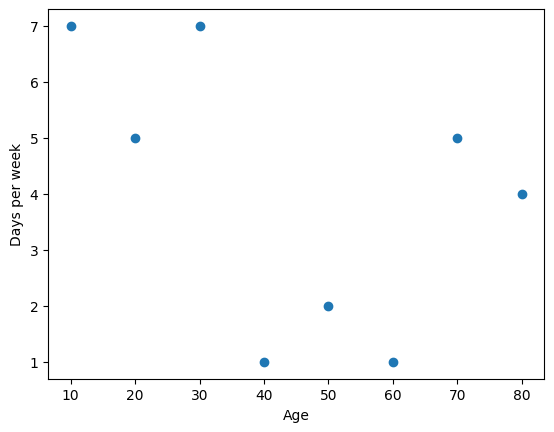

In [6]:
plt.scatter(features, labels)
plt.xlabel("Age")
plt.ylabel("Days per week")
plt.show()

### Fitting a decision tree

In [7]:
decision_tree_regressor = DecisionTreeRegressor(max_depth=2)
decision_tree_regressor.fit(features, labels)

DecisionTreeRegressor(max_depth=2)

### Ploting decision tree model

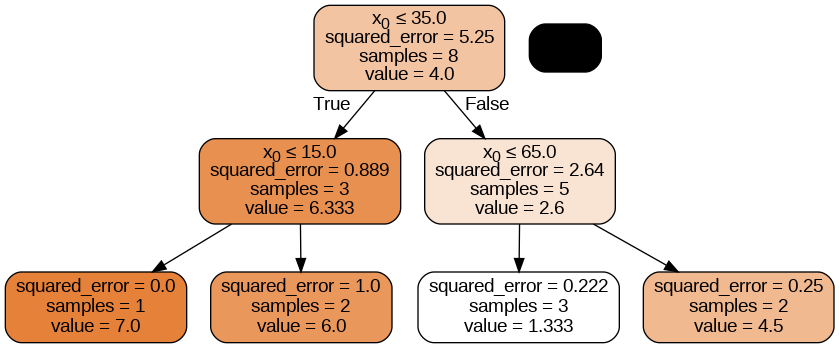

In [10]:
display_tree(decision_tree_regressor)

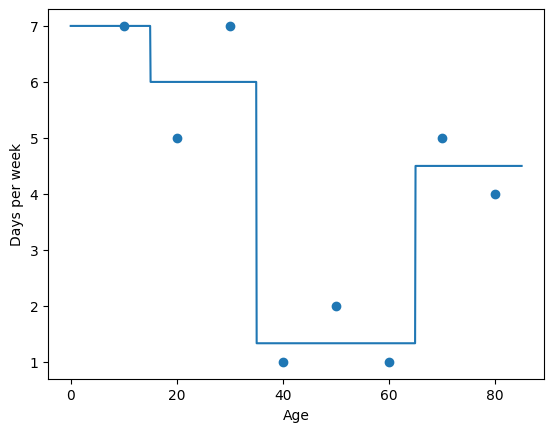

In [11]:
plot_regressor(decision_tree_regressor, features, labels)

## Gradient boosting

### First weak learner

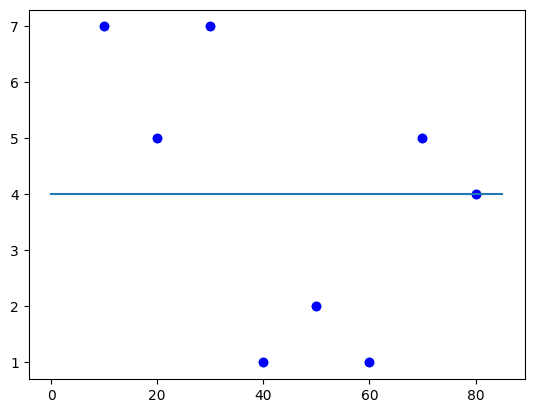

In [12]:
# First weak learner
x = np.linspace(0,85,2)
plt.scatter(features, labels)
plt.plot(x, [4 for i in range(len(x))])
plt.scatter(features, labels, color='blue')

### Traning Gradient boosting regressor

In [13]:
gradient_boosting_regressor = GradientBoostingRegressor(max_depth=2, n_estimators=4, learning_rate=0.8)
gradient_boosting_regressor.fit(features, labels)
gradient_boosting_regressor.predict(features)

array([6.87466667, 5.11466667, 6.71466667, 1.43466667, 1.43466667,
       1.43466667, 4.896     , 4.096     ])

### Plot the model

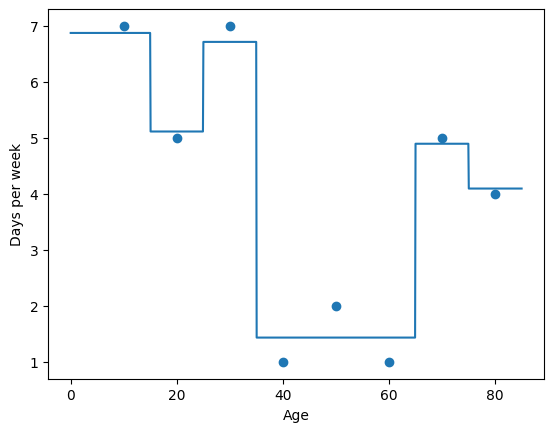

In [14]:
plot_regressor(gradient_boosting_regressor, features, labels)

### Plot individual weak learners from Gradient boosting model


**************************************************

Weak learner 1
Residuals to predict: [ 3.  1.  3. -3. -2. -3.  1.  0.]
Predictions: [ 3.          2.          2.         -2.66666667 -2.66666667 -2.66666667
  0.5         0.5       ]


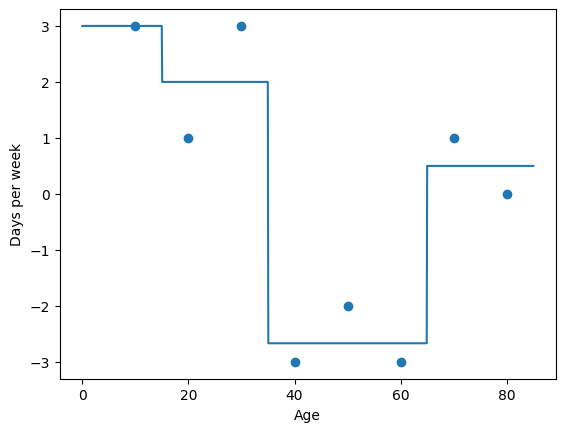

New residuals: [ 0.6        -0.6         1.4        -0.86666667  0.13333333 -0.86666667
  0.6        -0.4       ]

**************************************************

Weak learner 2
Residuals to predict: [ 0.6        -0.6         1.4        -0.86666667  0.13333333 -0.86666667
  0.6        -0.4       ]
Predictions: [ 0.          0.          1.4        -0.53333333 -0.53333333 -0.53333333
  0.1         0.1       ]


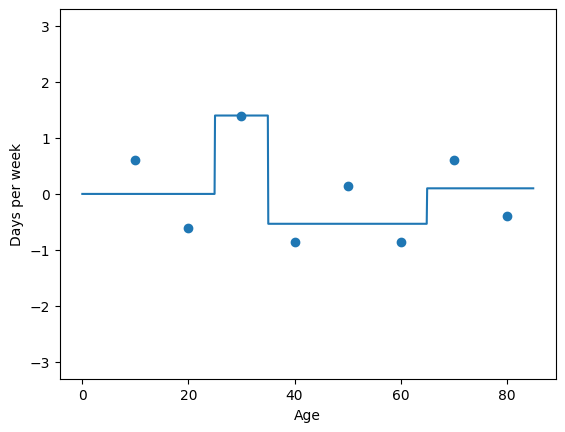

New residuals: [ 0.6  -0.6   0.28 -0.44  0.56 -0.44  0.52 -0.48]

**************************************************

Weak learner 3
Residuals to predict: [ 0.6  -0.6   0.28 -0.44  0.56 -0.44  0.52 -0.48]
Predictions: [ 6.00000000e-01 -6.00000000e-01 -7.40148683e-17 -7.40148683e-17
 -7.40148683e-17 -7.40148683e-17 -7.40148683e-17 -7.40148683e-17]


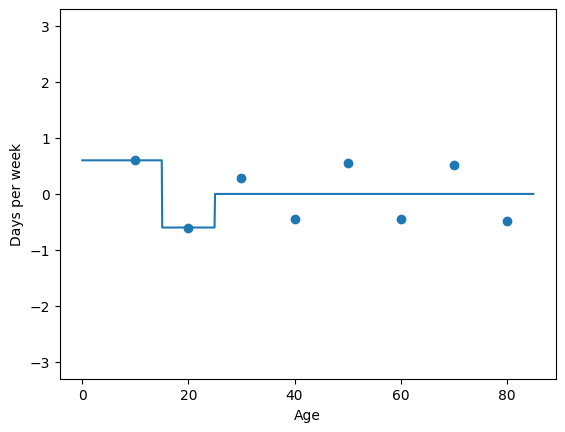

New residuals: [ 0.12 -0.12  0.28 -0.44  0.56 -0.44  0.52 -0.48]

**************************************************

Weak learner 4
Residuals to predict: [ 0.12 -0.12  0.28 -0.44  0.56 -0.44  0.52 -0.48]
Predictions: [-0.00666667 -0.00666667 -0.00666667 -0.00666667 -0.00666667 -0.00666667
  0.52       -0.48      ]


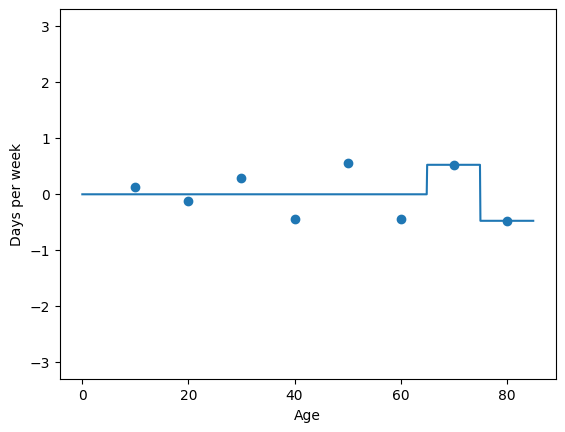

New residuals: [ 0.12533333 -0.11466667  0.28533333 -0.43466667  0.56533333 -0.43466667
  0.104      -0.096     ]


In [15]:
predictions_estimators = []
predictions = np.zeros(8)
centered_labels = labels-labels.mean()
residuals = [centered_labels]
for i in range(len(gradient_boosting_regressor.estimators_)):
    weak_learner = gradient_boosting_regressor.estimators_[i][0]
    print("\n"+"*"*50+"\n")
    print("Weak learner", i+1)
    preds = weak_learner.predict(features)
    predictions_estimators.append(preds)
    print("Residuals to predict:", residuals[-1])
    print("Predictions:", preds)
    predictions += preds*0.8
    #plt.scatter(features, predictions)
    #plt.scatter(features, residuals[-1])
    #plot_regressor(tree[0], features, centered_labels)
    plt.scatter(features, centered_labels, color='white')
    plot_regressor(weak_learner, features, residuals[-1])
    plt.show()
    residuals.append(centered_labels-predictions)
    print("New residuals:", residuals[-1])

### Predictions of the first i learners

Up to weak learner number 1


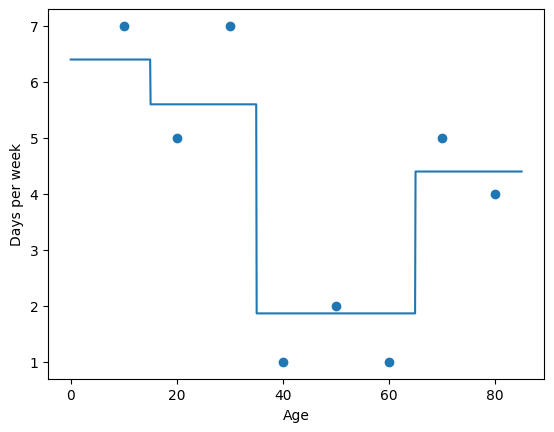

Up to weak learner number 2


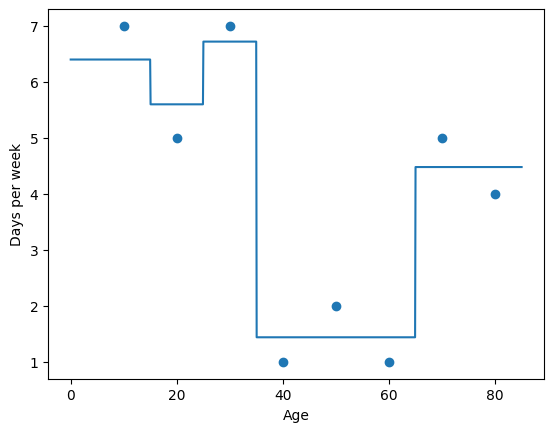

Up to weak learner number 3


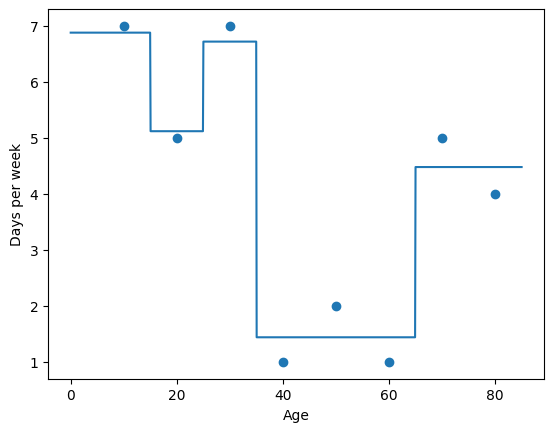

Up to weak learner number 4


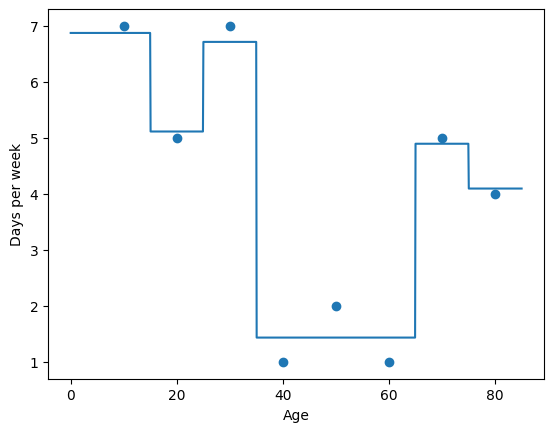

In [16]:
for i in range(1,5):
    print("Up to weak learner number", i)
    gb_intermediate = GradientBoostingRegressor(max_depth=2, n_estimators=i, learning_rate=0.8)
    gb_intermediate.fit(features, labels)
    predictions = gb_intermediate.predict(features)
    plot_regressor(gb_intermediate, features, labels)

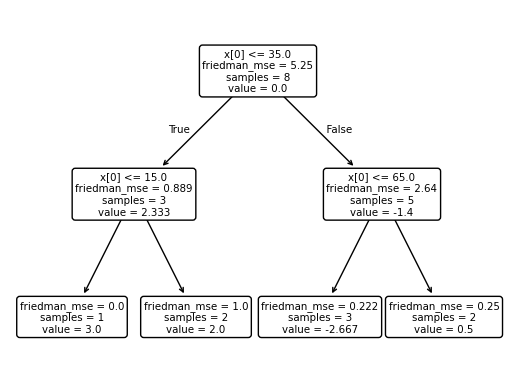

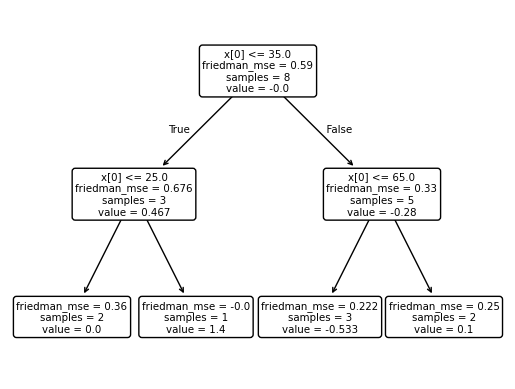

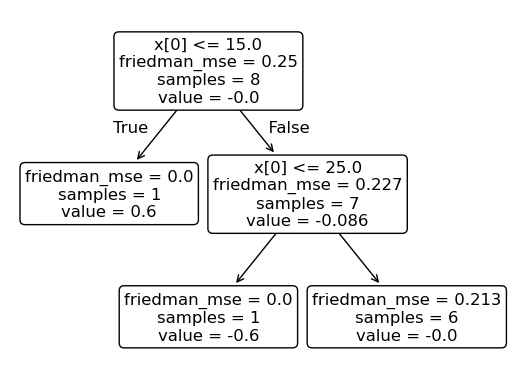

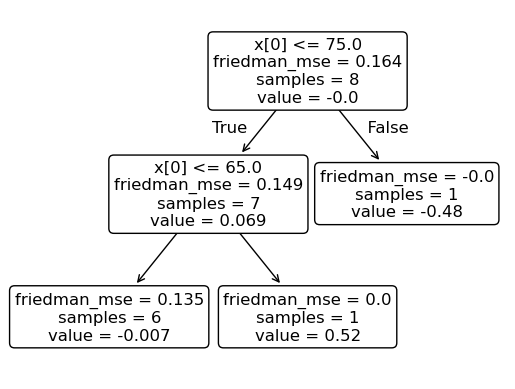

In [17]:
for tree in gradient_boosting_regressor.estimators_:
    sklearn.tree.plot_tree(tree[0], rounded=True)
    plt.show()

### Display Decision trees in gradient boosting regressors

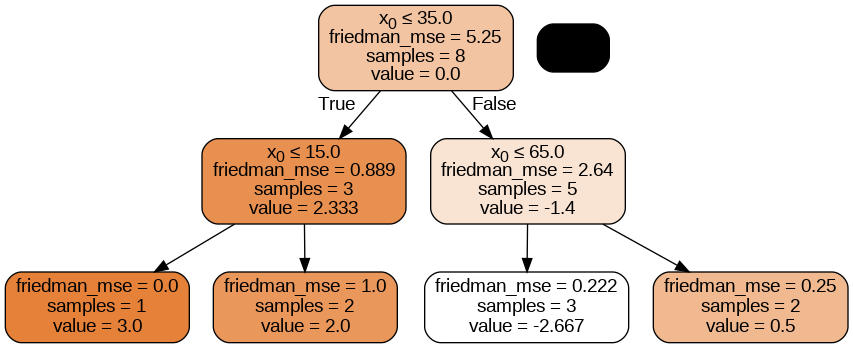

In [18]:
display_tree(gradient_boosting_regressor.estimators_[0][0])

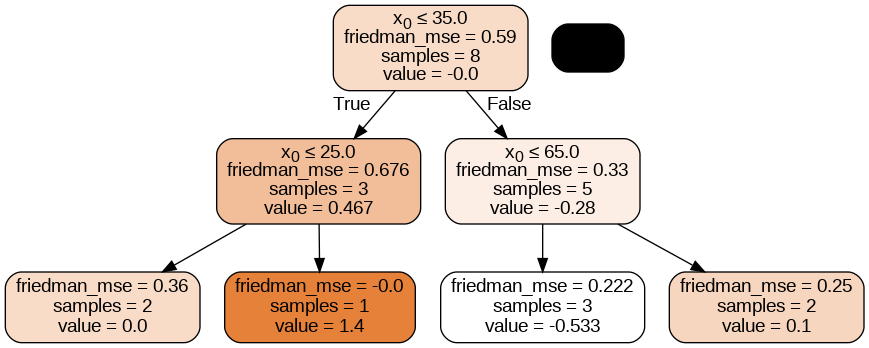

In [19]:
display_tree(gradient_boosting_regressor.estimators_[1][0])

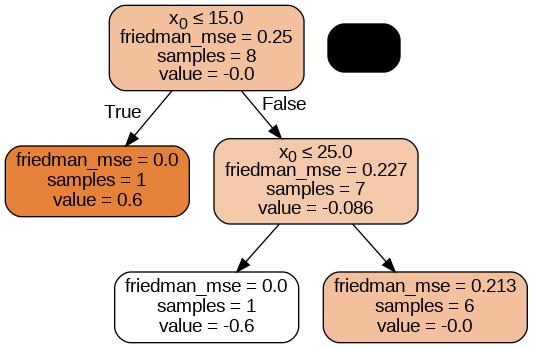

In [20]:
display_tree(gradient_boosting_regressor.estimators_[2][0])

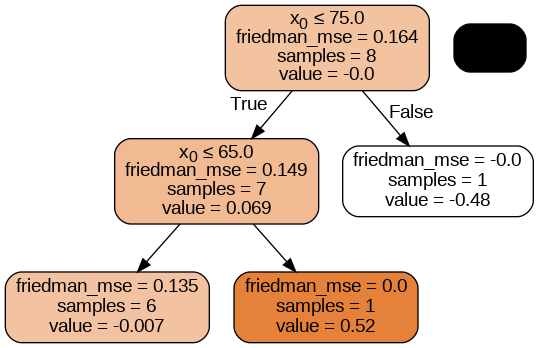

In [21]:
display_tree(gradient_boosting_regressor.estimators_[3][0])